/tmp/ipykernel_1044/2497924030.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_1044/2497924030.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

=== MODEL COMPARISON TABLE ===
| Model                   |   Accuracy |   Precision |   Recall |   F1-Score |
|:------------------------|-----------:|------------:|---------:|-----------:|
| Decision Tree (Single)  |   0.798883 |    0.753846 | 0.710145 |   0.731343 |
| Random Forest (Bagging) |   0.804469 |    0.765625 | 0.710145 |   0.736842 |
| XGBoost (Boosting)      |   0.798883 |    0.779661 | 0.666667 |   0.71875  |


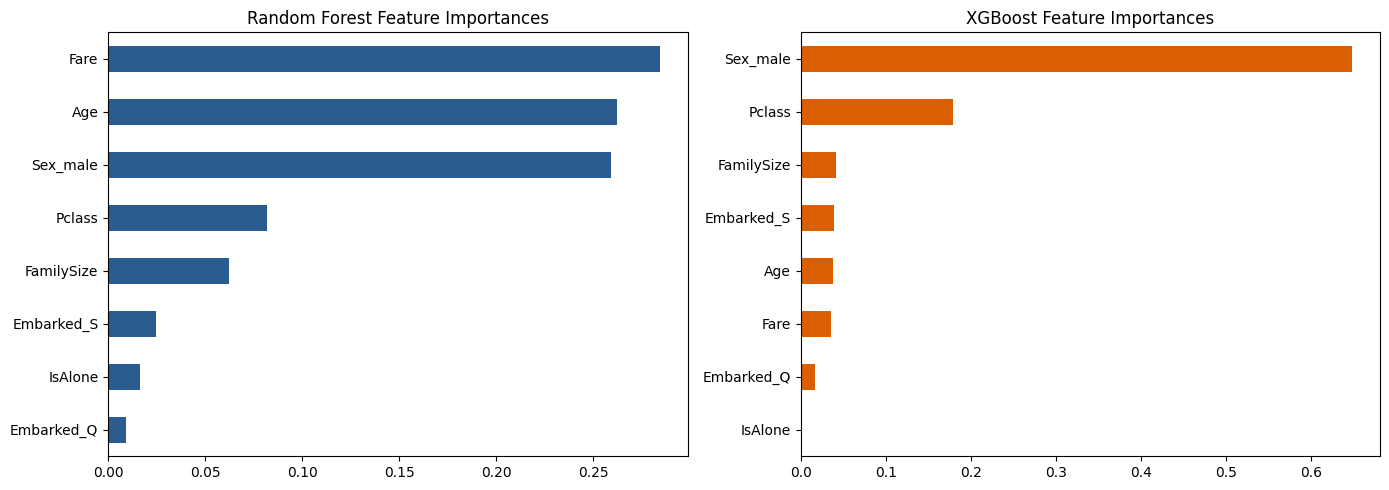

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

# 1. LOAD & PREPROCESS DATA
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Feature engineering
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Handle missing values & categorical encoding
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Select features
features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "FamilySize", "IsAlone"]
X = pd.get_dummies(df[features], drop_first=True)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. TRAIN MODELS
from sklearn.tree import DecisionTreeClassifier

# Single Baseline Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest Ensemble
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# XGBoost Ensemble
xgb_model = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
)
xgb_model.fit(X_train, y_train)

# 3. EVALUATION FUNCTION
def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
    }

results = pd.DataFrame(
    [
        evaluate_model(dt_model, X_test, y_test, "Decision Tree (Single)"),
        evaluate_model(rf_model, X_test, y_test, "Random Forest (Bagging)"),
        evaluate_model(xgb_model, X_test, y_test, "XGBoost (Boosting)"),
    ]
)

print("=== MODEL COMPARISON TABLE ===")
print(results.to_markdown(index=False))

# 4. PLOT FEATURE IMPORTANCES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Feature Importance
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
rf_importances.plot(kind="barh", ax=axes[0], color="#2b5c8f")
axes[0].set_title("Random Forest Feature Importances")

# XGBoost Feature Importance
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values()
xgb_importances.plot(kind="barh", ax=axes[1], color="#d95f02")
axes[1].set_title("XGBoost Feature Importances")

plt.tight_layout()
plt.show()

Conceptual Difference (For Writeup & README)
How Random Forest and XGBoost Differ:

Random Forest uses Bagging (Bootstrap Aggregating), where multiple independent decision trees are built in parallel on random subsets of data and features, and their individual predictions are averaged to reduce variance.

In contrast, XGBoost uses Gradient Boosting, where decision trees are built sequentially in series. Each new tree specifically focuses on correcting the residual errors and misclassifications made by the preceding trees, using gradient descent optimization to minimize prediction error.
